 PREDICTION DU DEFAUT DE 

                 Model  Accuracy  Precision    Recall        F1   ROC_AUC
2              XGBoost  0.815833   0.650407  0.361718  0.464891  0.774173
1        Random Forest  0.814500   0.648611  0.351922  0.456277  0.757861
0  Logistic Regression  0.679667   0.367247  0.620196  0.461323  0.708115

Best model : XGBoost


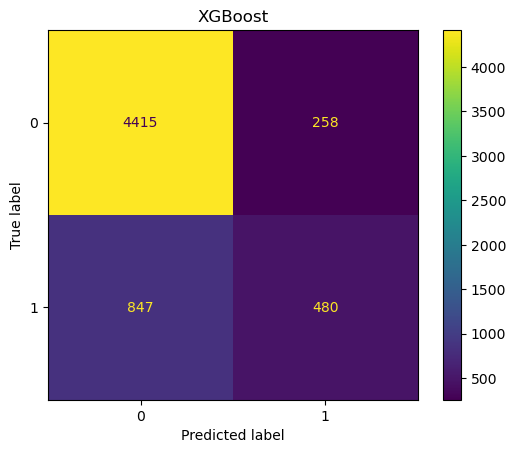

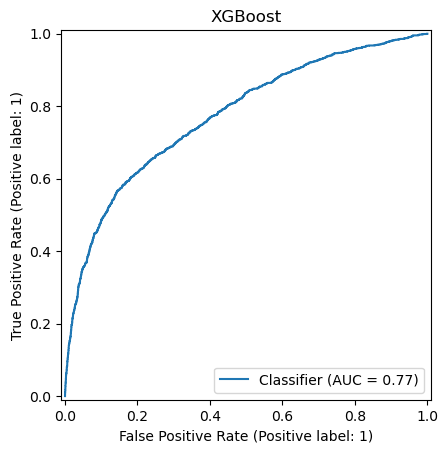

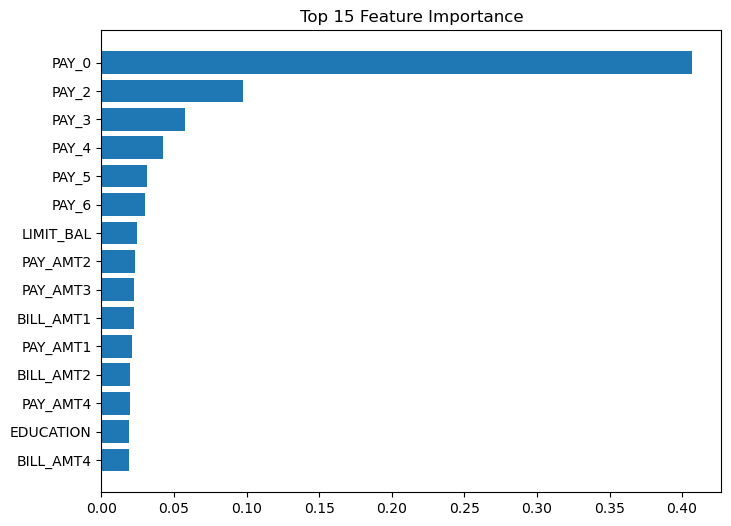


Files generated:
- Model_Comparison.csv
- PredictionClients.csv
- Best_Model.pkl
- FeatureImportance.csv


In [6]:
import warnings
warnings.filterwarnings("ignore")

import joblib
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import matplotlib.pyplot as plt

try:
    from xgboost import XGBClassifier
    HAS_XGB=True
except ImportError:
    HAS_XGB=False


# ------------------------------------------------------------------
# Load data
# ------------------------------------------------------------------
# Chargement de la base
df = pd.read_excel(
    r"C:\Users\mdiallo37\Desktop\Projet_linkedin\default of credit card clients.xls"
)

# Copie complète pour l'export Power BI
prediction = df.copy()

# Renommer la cible
df.rename(
    columns={"default payment next month": "Defaut"},
    inplace=True
)

prediction.rename(
    columns={"default payment next month": "Defaut"},
    inplace=True
)

df.rename(
    columns={"default payment next month": "Defaut"},
    inplace=True
)

# Les modèles ne doivent pas apprendre sur l'ID
X = df.drop(columns=["ID", "Defaut"], errors="ignore")

y = df["Defaut"]


X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,stratify=y,random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )
}

if HAS_XGB:
    models["XGBoost"] = XGBClassifier(
        objective="binary:logistic",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )

results=[]

def evaluate(name, model):

    if name=="Logistic Regression":
        model.fit(X_train_scaled,y_train)
        pred=model.predict(X_test_scaled)
        prob=model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train,y_train)
        pred=model.predict(X_test)
        prob=model.predict_proba(X_test)[:,1]

    return {
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred),
        "Recall":recall_score(y_test,pred),
        "F1":f1_score(y_test,pred),
        "ROC_AUC":roc_auc_score(y_test,prob),
        "Prediction":pred,
        "Probability":prob,
        "Estimator":model
    }

for n,m in models.items():
    results.append(evaluate(n,m))

comparison=pd.DataFrame([
    {
        "Model":r["Model"],
        "Accuracy":r["Accuracy"],
        "Precision":r["Precision"],
        "Recall":r["Recall"],
        "F1":r["F1"],
        "ROC_AUC":r["ROC_AUC"]
    }
    for r in results
]).sort_values("ROC_AUC",ascending=False)

print(comparison)

comparison.to_csv("Model_Comparison.csv",index=False)

best=max(results,key=lambda r:r["ROC_AUC"])

print(f"\nBest model : {best['Model']}")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    best["Prediction"]
)
plt.title(best["Model"])
plt.show()

RocCurveDisplay.from_predictions(
    y_test,
    best["Probability"]
)
plt.title(best["Model"])
plt.show()

estimator=best["Estimator"]

if best["Model"]!="Logistic Regression":
    importance=pd.DataFrame({
        "Variable":X.columns,
        "Importance":estimator.feature_importances_
    }).sort_values("Importance",ascending=False)

    importance.to_csv("FeatureImportance.csv",index=False)

    plt.figure(figsize=(8,6))
    plt.barh(
        importance["Variable"][:15],
        importance["Importance"][:15]
    )
    plt.gca().invert_yaxis()
    plt.title("Top 15 Feature Importance")
    plt.show()

# ===========================================================
# Création du fichier destiné à Power BI
# ===========================================================

X_prediction = prediction.drop(
    columns=["ID", "Defaut"],
    errors="ignore"
)

if best["Model"] == "Logistic Regression":

    prediction["Probabilite_Defaut"] = estimator.predict_proba(
        scaler.transform(X_prediction)
    )[:,1]

else:

    prediction["Probabilite_Defaut"] = estimator.predict_proba(
        X_prediction
    )[:,1]

prediction["Prediction"]=(prediction["Probabilite_Defaut"]>=0.5).astype(int)

prediction["Niveau_Risque"] = pd.cut(
    prediction["Probabilite_Defaut"],
    bins=[0,0.25,0.50,0.75,1],
    labels=[
        "Faible",
        "Moyen",
        "Élevé",
        "Très élevé"
    ],
    include_lowest=True
)

prediction = prediction[[
    "ID",
    "LIMIT_BAL",
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",
    "Defaut",
    "Probabilite_Defaut",
    "Prediction",
    "Niveau_Risque"
]]

prediction.to_csv(
    "PredictionClients.csv",
    index=False
)

joblib.dump(estimator,"Best_Model.pkl")

print("\nFiles generated:")
print("- Model_Comparison.csv")
print("- PredictionClients.csv")
print("- Best_Model.pkl")
if best["Model"]!="Logistic Regression":
    print("- FeatureImportance.csv")
